# Previsão da linha de atuação parlamentar a partir do perfil eleitoral

Previsão da linha de atuação (governista × oposição) de deputados federais a partir
do perfil eleitoral registrado no TSE, antes da eleição.

O notebook parte da base já coletada e integrada `dataset.csv` e segue as etapas da
disciplina:

1. **Limpeza de dados** — tipo/escala dos atributos, seleção de atributos, valores ausentes, instâncias duplicadas, outliers
2. **Exploração (estatística descritiva)** — frequência, localidade, dispersão, distribuição, correlação
3. **Transformação** — conversão simbólico→numérico (One-Hot) e normalização
4. **Modelagem** — múltiplos algoritmos comparados por acurácia/F1 para escolher o melhor
5. **Validação** — validação cruzada estratificada repetida, matriz de confusão e análise de erros do modelo escolhido

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
df = pd.read_csv('dataset.csv')
print('instâncias, atributos:', df.shape)

instâncias, atributos: (590, 16)


# 1. Limpeza de dados

## 1.1 Conheça seus dados

Antes de qualquer transformação, uma olhada direta na base (*"uma simples olhada em uma planilha pode fazer toda a diferença"*).

In [2]:
df.head()

,idDeputado,nome,cpf,partido,federacao,uf,regiao,idade,genero,grau_instrucao,cor_raca,ocupacao,patrimonio_total,pct_alinhamento_gov,n_votacoes,rotulo
0,62881,Danilo Forte,12133728368,UNIÃO,#NULO,CE,NE,64,MASCULINO,SUPERIOR COMPLETO,BRANCA,ADVOGADO,3231234.32,0.7630,270,governista
1,66385,Julio Arcoverde,77309766768,PP,#NULO,PI,NE,56,MASCULINO,SUPERIOR COMPLETO,PARDA,DEPUTADO,2346554.16,0.8344,308,governista
2,66828,Fausto Pinato,28022995819,PP,#NULO,SP,SE,45,MASCULINO,SUPERIOR COMPLETO,BRANCA,ADVOGADO,712867.36,0.8556,284,governista
3,68720,Fábio Henrique,41330200578,UNIÃO,#NULO,SE,NE,50,MASCULINO,SUPERIOR COMPLETO,PARDA,OUTROS,760000.00,0.8571,49,governista
4,69871,Bacelar,10626409500,PV,PT/PC do B/PV,BA,NE,65,MASCULINO,SUPERIOR COMPLETO,BRANCA,DEPUTADO,462181.22,1.0000,340,governista


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   idDeputado           590 non-null    int64  
 1   nome                 590 non-null    str    
 2   cpf                  590 non-null    int64  
 3   partido              590 non-null    str    
 4   federacao            590 non-null    str    
 5   uf                   590 non-null    str    
 6   regiao               590 non-null    str    
 7   idade                590 non-null    int64  
 8   genero               590 non-null    str    
 9   grau_instrucao       590 non-null    str    
 10  cor_raca             590 non-null    str    
 11  ocupacao             590 non-null    str    
 12  patrimonio_total     590 non-null    float64
 13  pct_alinhamento_gov  590 non-null    float64
 14  n_votacoes           590 non-null    int64  
 15  rotulo               590 non-null    str    
dtypes

## 1.2 Tipo e escala dos atributos

Cada coluna é classificada quanto ao **tipo** (numérico / nominal) e à **escala** (nominal, ordinal, racional), o que determina o tratamento posterior.

| Atributo | Tipo | Escala | Papel |
|---|---|---|---|
| `idDeputado`, `nome`, `cpf` | — | — | identificador (descartar) |
| `partido`, `federacao`, `uf`, `genero`, `cor_raca`, `ocupacao` | nominal | nominal | feature categórica |
| `regiao` | nominal | nominal | feature categórica |
| `grau_instrucao` | nominal | ordinal | feature categórica (tratada como nominal) |
| `idade` | numérico | racional | feature numérica |
| `patrimonio_total` | numérico | racional | feature numérica |
| `pct_alinhamento_gov`, `n_votacoes` | numérico | racional | pós-eleição → vazamento (descartar) |
| `rotulo` | nominal | nominal | **alvo** |

## 1.3 Seleção adequada de atributos

Removem-se atributos que não devem entrar no modelo:

- **Irrelevantes para o que se deseja aprender** (como *"nome do paciente"* nos slides): `idDeputado`, `nome`, `cpf` — identificadores sem poder preditivo.
- **Vazamento de dados** (*data leakage*): `pct_alinhamento_gov` e `n_votacoes` derivam do comportamento de voto **posterior** à eleição — a mesma informação que origina o rótulo. Usá-las como feature seria "trapacear".

Ficam apenas as features do TSE, todas anteriores à eleição.

In [4]:
CATEGORICAS = ['partido', 'federacao', 'uf', 'regiao', 'genero',
               'grau_instrucao', 'cor_raca', 'ocupacao']
NUMERICAS = ['idade', 'patrimonio_total']

descartar = ['idDeputado', 'nome', 'cpf', 'pct_alinhamento_gov', 'n_votacoes']
print('atributos descartados:', descartar)

X = df[CATEGORICAS + NUMERICAS].copy()
y = df['rotulo'].copy()
print('features mantidas:', X.shape[1], '|', list(X.columns))

atributos descartados: ['idDeputado', 'nome', 'cpf', 'pct_alinhamento_gov', 'n_votacoes']
features mantidas: 10 | ['partido', 'federacao', 'uf', 'regiao', 'genero', 'grau_instrucao', 'cor_raca', 'ocupacao', 'idade', 'patrimonio_total']


## 1.4 Valores ausentes

Tratamento possível (slides): **descarte** (evita introdução de erros, mas pode reduzir a amostra) ou **estimação** (nominais → moda; contínuos → média). A decisão depende de **verificar** se há ausência. Auditoria em três frentes.

In [5]:
# (a) valores nulos (NaN / vazios)
nulos = df.isnull().sum()
print('total de células nulas:', int(nulos.sum()))
print('linhas com algum nulo :', int(df.isnull().any(axis=1).sum()))

total de células nulas: 0
linhas com algum nulo : 0


In [6]:
# (b) marcadores de ausência usados pelo TSE (#NULO, #NE, -1) — não viram NaN automaticamente
marcadores = ['#NULO', '#NE', '#NI', 'NÃO INFORMADO', '-1', '']
achados = {c: int(df[c].isin(marcadores).sum())
           for c in df.select_dtypes(include='object').columns
           if df[c].isin(marcadores).sum() > 0}
print('marcadores de ausência encontrados:', achados if achados else 'NENHUM')

marcadores de ausência encontrados: {'federacao': 472, 'cor_raca': 1}


/tmp/ipykernel_1288079/2381909291.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns


In [7]:
# (c) consistência das variáveis numéricas
print('idade — min:', df['idade'].min(), '| max:', df['idade'].max(),
      '| fora da faixa (<=0 ou >100):', int(((df['idade'] <= 0) | (df['idade'] > 100)).sum()))
print('patrimonio_total negativo:', int((df['patrimonio_total'] < 0).sum()))
print('patrimonio_total == 0    :', int((df['patrimonio_total'] == 0).sum()),
      '(sem bens declarados — valor real, não ausente)')

idade — min: 21 | max: 88 | fora da faixa (<=0 ou >100): 0
patrimonio_total negativo: 0
patrimonio_total == 0    : 22 (sem bens declarados — valor real, não ausente)


**Decisão — não descartar nenhuma linha.** As verificações não encontraram dados ausentes: a junção por CPF é *inner* (não gera linha órfã com campos vazios, e o casamento foi 590/590), o único marcador do TSE (`#NULO` em `federacao`) já foi convertido na categoria `SEM` durante a coleta (ausência **informativa**, não faltante), e `patrimonio_total = 0` é valor verdadeiro. Como salvaguarda, o pipeline (§3) ainda inclui imputação (moda para nominais, mediana para numéricas), de modo que qualquer ausência residual seria estimada — sem perder instâncias.

In [8]:
# confirmação: o descarte não remove nada
antes = len(df)
_ = df.dropna()
print('linhas que seriam removidas por descarte de ausentes:', antes - len(_))

linhas que seriam removidas por descarte de ausentes: 0


## 1.5 Instâncias duplicadas

Duplicatas podem ser **ilegítimas** (mesmo deputado repetido) ou **legítimas** (dois deputados com o mesmo perfil). Verifica-se pela chave única (`cpf`).

In [9]:
print('linhas totais        :', len(df))
print('CPFs únicos          :', df['cpf'].nunique())
print('linhas inteiras dup. :', int(df.duplicated().sum()))
print('CPFs duplicados      :', int(df['cpf'].duplicated().sum()), '(0 = nenhuma duplicata ilegítima)')

linhas totais        : 590
CPFs únicos          : 590
linhas inteiras dup. : 0
CPFs duplicados      : 0 (0 = nenhuma duplicata ilegítima)


## 1.6 Outliers

Instâncias "anômalas", com valor muito diferente da maioria. `patrimonio_total` é o caso mais sensível (varia de 0 a centenas de milhões).

/tmp/ipykernel_1288079/4195381734.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[0].boxplot(df['patrimonio_total'] / 1e6, vert=False)
/tmp/ipykernel_1288079/4195381734.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df['idade'], vert=False)


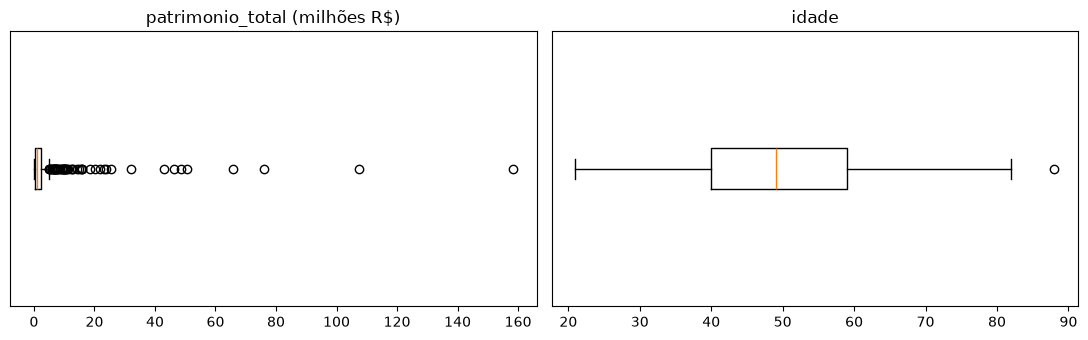

patrimônio acima do limite do boxplot (outliers): 56


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].boxplot(df['patrimonio_total'] / 1e6, vert=False)
ax[0].set_title('patrimonio_total (milhões R$)'); ax[0].set_yticks([])
ax[1].boxplot(df['idade'], vert=False)
ax[1].set_title('idade'); ax[1].set_yticks([])
plt.tight_layout(); plt.show()

q1, q3 = df['patrimonio_total'].quantile([0.25, 0.75])
lim_sup = q3 + 1.5 * (q3 - q1)
print('patrimônio acima do limite do boxplot (outliers):',
      int((df['patrimonio_total'] > lim_sup).sum()))

**Decisão — manter os outliers de patrimônio.** São valores **reais** (deputados de patrimônio muito alto existem), não erros de medição. Remover enviesaria a amostra. O efeito de escala é tratado na normalização (§3.2), e os modelos baseados em árvore são robustos a outliers.

# 2. Exploração (estatística descritiva)

Análise para conhecer o comportamento dos dados antes de modelar.

## 2.1 Univariada — Frequência

Frequência absoluta e relativa das variáveis nominais e do alvo.

In [11]:
# alvo: frequência absoluta e relativa
freq = df['rotulo'].value_counts()
rel = df['rotulo'].value_counts(normalize=True).round(3)
print('rótulo — frequência absoluta:\n', freq.to_string(), sep='')
print('\nrótulo — frequência relativa:\n', rel.to_string(), sep='')

rótulo — frequência absoluta:
rotulo
governista    435
oposicao      155

rótulo — frequência relativa:
rotulo
governista    0.737
oposicao      0.263


In [12]:
# partido: 10 mais frequentes
df['partido'].value_counts().head(10)

partido
PL              112
PT               72
UNIÃO            67
PSD              57
PP               56
MDB              48
REPUBLICANOS     47
PDT              21
PODE             15
PSB              14
Name: count, dtype: int64

## 2.2 Univariada — Localidade e Dispersão

Medidas de **localidade** (mínimo, máximo, média, mediana, moda) e de **dispersão** (amplitude, desvio padrão, variância) das variáveis numéricas.

In [13]:
resumo = pd.DataFrame({
    'minimo':   df[NUMERICAS].min(),
    'maximo':   df[NUMERICAS].max(),
    'media':    df[NUMERICAS].mean(),
    'mediana':  df[NUMERICAS].median(),
    'amplitude': df[NUMERICAS].max() - df[NUMERICAS].min(),
    'desvio_padrao': df[NUMERICAS].std(),
    'variancia': df[NUMERICAS].var(),
}).round(2)
resumo

,minimo,maximo,media,mediana,amplitude,desvio_padrao,variancia
idade,21.0,8.800000e+01,49.91,49.0,6.700000e+01,12.23,1.496500e+02
patrimonio_total,0.0,1.581845e+08,2990167.15,945945.1,1.581845e+08,10061051.07,1.012247e+14


## 2.3 Univariada — Distribuição

Histograma e **assimetria (skewness)** das numéricas. Espera-se forte assimetria à direita em `patrimonio_total` (poucos com patrimônio muito alto).

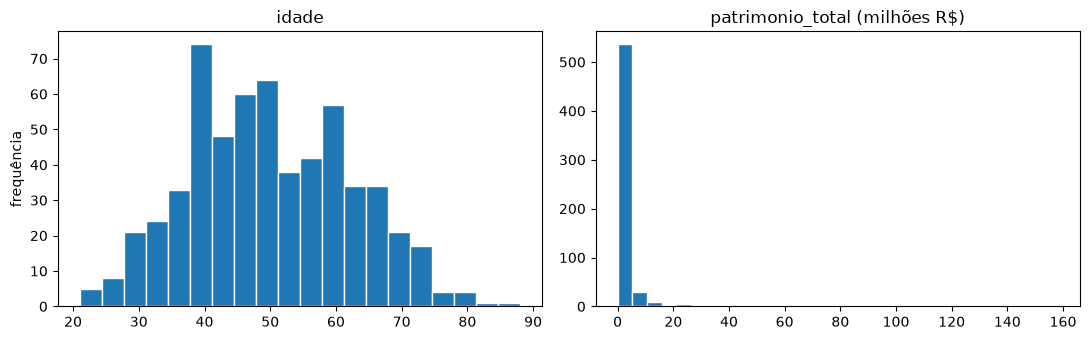

assimetria (skewness):
  idade           : 0.18
  patrimonio_total: 9.953 (>0 = cauda à direita)


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df['idade'], bins=20, edgecolor='white')
ax[0].set_title('idade'); ax[0].set_ylabel('frequência')
ax[1].hist(df['patrimonio_total'] / 1e6, bins=30, edgecolor='white')
ax[1].set_title('patrimonio_total (milhões R$)')
plt.tight_layout(); plt.show()

print('assimetria (skewness):')
print('  idade           :', round(df['idade'].skew(), 3))
print('  patrimonio_total:', round(df['patrimonio_total'].skew(), 3), '(>0 = cauda à direita)')

## 2.4 Multivariada — Correlação

Correlação de Pearson entre as variáveis numéricas e o **alvo** (codificado 1 =
governista, 0 = oposição — correlação ponto-bisserial). Valores próximos de 0
indicam ausência de relação linear.

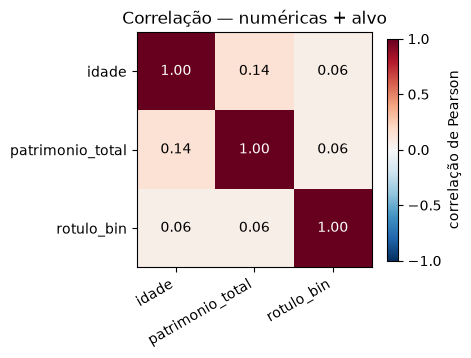

In [15]:
# matriz de correlação: numéricas + alvo binário
corr = (df[NUMERICAS]
        .assign(rotulo_bin=(df['rotulo'] == 'governista').astype(int))
        .corr())

fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=30, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8, label='correlação de Pearson')
ax.set_title('Correlação — numéricas + alvo')
plt.tight_layout(); plt.show()

## 2.5 Bivariada — atributos × alvo

A correlação de Pearson só cobre as numéricas. Para entender a relação das
**categóricas** com o alvo, compara-se a taxa de governismo dentro de cada
categoria com a taxa global (73,7%): categoria cuja taxa foge muito da global
carrega informação preditiva.

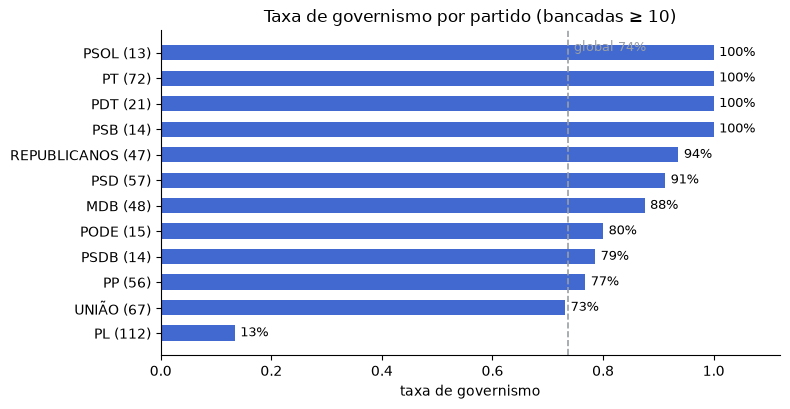

In [16]:
# taxa de governismo por partido (bancadas com 10+ deputados)
taxa_global = (df['rotulo'] == 'governista').mean()
bancadas = df.groupby('partido').filter(lambda g: len(g) >= 10)
taxa = (bancadas.assign(gov=bancadas['rotulo'] == 'governista')
        .groupby('partido').agg(n=('gov', 'size'), taxa=('gov', 'mean'))
        .sort_values('taxa'))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh([f'{p} ({int(r.n)})' for p, r in taxa.iterrows()], taxa['taxa'],
        color='#4269d0', height=0.6)
ax.axvline(taxa_global, color='#9aa0a6', linestyle='--', linewidth=1.2)
ax.text(taxa_global + 0.01, len(taxa) - 0.5, f'global {taxa_global:.0%}',
        color='#9aa0a6', fontsize=9, va='top')
for i, v in enumerate(taxa['taxa']):
    ax.text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=9)
ax.set_xlim(0, 1.12); ax.set_xlabel('taxa de governismo')
ax.set_title('Taxa de governismo por partido (bancadas ≥ 10)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

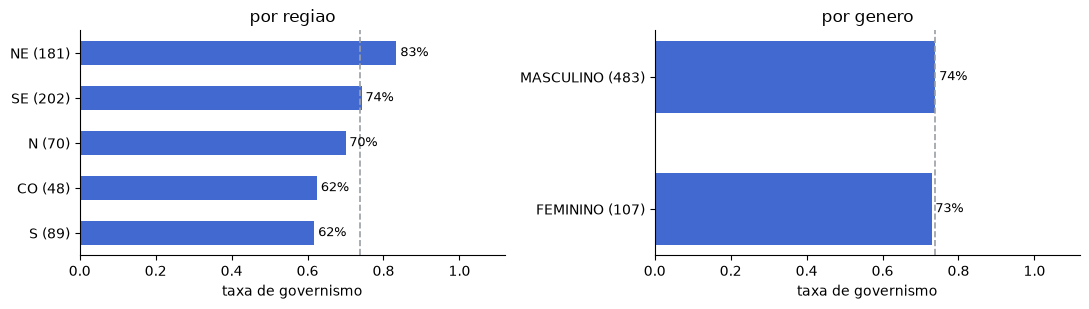

In [17]:
# taxa de governismo por região e por gênero
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, col in zip(axes, ['regiao', 'genero']):
    t = (df.assign(gov=df['rotulo'] == 'governista')
         .groupby(col).agg(n=('gov', 'size'), taxa=('gov', 'mean'))
         .sort_values('taxa'))
    ax.barh([f'{k} ({int(r.n)})' for k, r in t.iterrows()], t['taxa'],
            color='#4269d0', height=0.55)
    ax.axvline(taxa_global, color='#9aa0a6', linestyle='--', linewidth=1.2)
    for i, v in enumerate(t['taxa']):
        ax.text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=9)
    ax.set_xlim(0, 1.12); ax.set_title(f'por {col}')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_xlabel('taxa de governismo'); axes[1].set_xlabel('taxa de governismo')
plt.tight_layout(); plt.show()

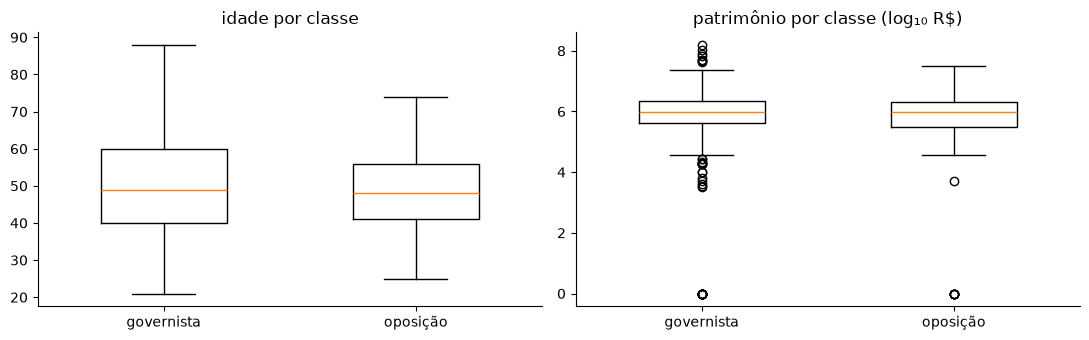

mediana idade      — gov: 49.0 | opo: 48.0
mediana patrimônio — gov: R$ 942,189 | opo: R$ 959,045


In [18]:
# numéricas × alvo: distribuição de idade e patrimônio por classe
grupos = [df.loc[df['rotulo'] == r] for r in ['governista', 'oposicao']]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].boxplot([g['idade'] for g in grupos],
                tick_labels=['governista', 'oposição'], widths=0.5)
axes[0].set_title('idade por classe')
axes[1].boxplot([np.log10(g['patrimonio_total'] + 1) for g in grupos],
                tick_labels=['governista', 'oposição'], widths=0.5)
axes[1].set_title('patrimônio por classe (log₁₀ R$)')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print('mediana idade      — gov:', grupos[0]['idade'].median(), '| opo:', grupos[1]['idade'].median())
print('mediana patrimônio — gov: R$ {:,.0f} | opo: R$ {:,.0f}'.format(
    grupos[0]['patrimonio_total'].median(), grupos[1]['patrimonio_total'].median()))

**Leitura da exploração:**

- **As numéricas quase não carregam sinal linear sobre o alvo** (correlação
  ponto-bisserial ≈ 0.06 para idade e patrimônio) — visível também nos boxplots:
  medianas de idade (49 × 48) e patrimônio (R$ 942 mil × R$ 959 mil) praticamente
  iguais entre as classes.
- **O partido estratifica fortemente o alvo:** PL com 13% de governismo num extremo;
  PT, PDT, PSB e PSOL com 100% no outro; e o centrão em posição intermediária —
  UNIÃO (73%) e PP (77%) coladas na taxa global, ou seja, legendas **divididas**,
  onde o partido sozinho não decide.
- **Região tem sinal moderado** (NE 83% × S/CO 62%); **gênero, nenhum** (73% × 74%).

Esta leitura antecipa o que se espera da modelagem: atributos categóricos (partido à
frente) devem dominar a previsão, e os casos difíceis devem se concentrar nas
legendas divididas.

# 3. Transformação

Várias técnicas de AM exigem atributos numéricos. Converte-se o simbólico em numérico e ajusta-se a escala.

## 3.1 Conversão simbólico → numérico

### Rótulo (nominal com 2 valores → dígito binário)
`governista` → 1, `oposicao` → 0.

In [19]:
y = (y == 'governista').astype(int)
y.value_counts()

rotulo
1    435
0    155
Name: count, dtype: int64

### Categóricas nominais com mais de 2 valores → "sequência de bits" (One-Hot Encoding)

Cada valor possível vira uma coluna com 1 bit em 1 e os demais em 0 (Abordagem 1 dos slides). `handle_unknown='ignore'` evita erro quando surge uma categoria não vista na validação. Abaixo, quantas colunas cada atributo gera.

In [20]:
X[CATEGORICAS].nunique()

partido           23
federacao          4
uf                27
regiao             5
genero             2
grau_instrucao     6
cor_raca           6
ocupacao          50
dtype: int64

## 3.2 Normalização (variância e média)

`idade` e `patrimonio_total` estão em escalas muito diferentes — sem ajuste, `patrimonio_total` (até ~1,6×10⁸) dominaria qualquer atributo. Aplica-se a **normalização por variância e média** (`StandardScaler`):

$$\hat{x} = \frac{x - \mu}{\sigma}$$

resultando em média 0 e desvio padrão 1.

## 3.3 Pipeline de transformação

One-Hot (categóricas) + normalização (numéricas) reunidos em um `ColumnTransformer`. Encapsulado em `Pipeline`, o `fit` ocorre **apenas no treino** de cada *fold* da validação — evitando vazamento do conjunto de teste.

In [21]:
preprocessador = ColumnTransformer([
    ('cat', Pipeline([
        ('imput', SimpleImputer(strategy='most_frequent')),   # estima nominais pela moda
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), CATEGORICAS),
    ('num', Pipeline([
        ('imput', SimpleImputer(strategy='median')),          # estima numéricas pela mediana
        ('escala', StandardScaler()),                          # normalização variância e média
    ]), NUMERICAS),
])

X_proc = preprocessador.fit_transform(X)
print('matriz de atributos processada:', X_proc.shape)

matriz de atributos processada: (590, 125)


In [22]:
nomes = preprocessador.get_feature_names_out()
print('colunas após One-Hot + normalização:', len(nomes))
print('exemplos:', list(nomes[:4]), '...', list(nomes[-2:]))

colunas após One-Hot + normalização: 125
exemplos: ['cat__partido_AVANTE', 'cat__partido_CIDADANIA', 'cat__partido_MDB', 'cat__partido_NOVO'] ... ['num__idade', 'num__patrimonio_total']


# Resultado do pré-processamento

- `X_proc` — matriz de atributos pronta (One-Hot nas categóricas + numéricas normalizadas), sem identificadores e sem vazamento.
- `y` — alvo binário (1 = governista, 0 = oposição).
- `preprocessador` — objeto reutilizável, acoplado a cada modelo na etapa de modelagem (seção 4), garantindo ajuste apenas sobre os dados de treino.

In [23]:
print('X_proc:', X_proc.shape)
print('y     :', y.shape, '| governistas:', int(y.sum()), '| oposição:', int((y == 0).sum()))

X_proc: (590, 125)
y     : (590,) | governistas: 435 | oposição: 155


# 4. Modelagem

Aplicação de **múltiplos algoritmos de classificação** sobre a matriz pré-processada,
comparando acurácia e F1 para decidir empiricamente qual funciona melhor neste
problema.

## 4.1 Protocolo

1. **Divisão treino/teste (holdout estratificado):** 75% treino / 25% teste,
   preservando a proporção das classes (73,7% governista / 26,3% oposição).
2. **Ajuste de hiperparâmetros só no treino:** cada algoritmo passa por uma busca em
   grade (`GridSearchCV`) usando somente o conjunto de treino. O conjunto de teste
   nunca é visto durante o ajuste.
3. **Comparação no teste:** os melhores modelos de cada algoritmo são avaliados no
   conjunto de teste com **acurácia** e **F1-macro**.
4. **Métrica de decisão — F1-macro:** a base é desbalanceada (435×155); um modelo que
   chuta "governista" para todos já atinge 73,7% de acurácia. O F1-macro dá o mesmo
   peso às duas classes e pune esse colapso.
5. Cada modelo roda dentro de um `Pipeline` com o `preprocessador` da §3.3 — o
   One-Hot e a normalização são ajustados apenas nos dados de treino de cada ajuste.

> A **validação aprofundada** do modelo escolhido (validação cruzada completa,
> matriz de confusão, análise de erros) é feita na etapa seguinte do trabalho.

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('treino:', X_treino.shape[0], '| teste:', X_teste.shape[0])
print('proporção governista — treino:', round(y_treino.mean(), 3),
      '| teste:', round(y_teste.mean(), 3))

treino: 442 | teste: 148
proporção governista — treino: 0.738 | teste: 0.736


## 4.2 Algoritmos e hiperparâmetros

Algoritmos vistos na disciplina, cada um com uma busca **leve** de hiperparâmetros
(`GridSearchCV`, avaliando por F1-macro em validação cruzada interna de 5 partições
**apenas no conjunto de treino**):

| Algoritmo | Grade de hiperparâmetros | Por que este algoritmo |
|---|---|---|
| Baseline (`DummyClassifier`) | — | régua mínima: sempre prevê a classe majoritária |
| KNN | `n_neighbors ∈ {3,5,9,15,21}`, `weights ∈ {uniform, distance}` | baseado em distância — depende diretamente da normalização feita no pré-processamento |
| Árvore de Decisão | `max_depth ∈ {3,5,8,None}`, `min_samples_leaf ∈ {1,5,10}`, `class_weight=balanced` | interpretável: as regras aprendidas podem ser lidas e discutidas |
| Random Forest | `n_estimators ∈ {100, 300}`, `max_depth ∈ {8, None}`, `min_samples_leaf ∈ {1, 5}`, `class_weight=balanced` | conjunto (*ensemble*) de árvores — reduz a variância da árvore única via *bagging* + sorteio de atributos |
| MLP | `hidden_layer_sizes ∈ {(32,),(64,),(32,16)}`, `alpha ∈ {10⁻³,10⁻²}` | contraste não-linear; redes pequenas + regularização por causa da amostra reduzida (590) |

A grade é pequena de propósito: o objetivo é justificar os parâmetros com evidência,
não uma otimização exaustiva.

In [25]:
modelos = {
    'Baseline (majoritária)': (DummyClassifier(strategy='most_frequent'), {}),
    'KNN': (KNeighborsClassifier(), {
        'clf__n_neighbors': [3, 5, 9, 15, 21],
        'clf__weights': ['uniform', 'distance'],
    }),
    'Árvore de Decisão': (DecisionTreeClassifier(random_state=42, class_weight='balanced'), {
        'clf__max_depth': [3, 5, 8, None],
        'clf__min_samples_leaf': [1, 5, 10],
    }),
    'Random Forest': (RandomForestClassifier(random_state=42, class_weight='balanced'), {
        'clf__n_estimators': [100, 300],
        'clf__max_depth': [8, None],
        'clf__min_samples_leaf': [1, 5],
    }),
    'MLP': (MLPClassifier(random_state=42, max_iter=2000), {
        'clf__hidden_layer_sizes': [(32,), (64,), (32, 16)],
        'clf__alpha': [1e-3, 1e-2],
    }),
}
print('algoritmos:', list(modelos.keys()))

algoritmos: ['Baseline (majoritária)', 'KNN', 'Árvore de Decisão', 'Random Forest', 'MLP']


In [26]:
resultados = []
buscas = {}
for nome, (modelo, grid) in modelos.items():
    pipe = Pipeline([('pre', preprocessador), ('clf', modelo)])
    busca = GridSearchCV(pipe, grid, scoring='f1_macro', cv=5, n_jobs=-1)
    busca.fit(X_treino, y_treino)
    pred = busca.predict(X_teste)
    resultados.append({
        'modelo': nome,
        'acuracia': accuracy_score(y_teste, pred),
        'f1_macro': f1_score(y_teste, pred, average='macro'),
        'melhores_parametros': {k.replace('clf__', ''): v for k, v in busca.best_params_.items()},
    })
    buscas[nome] = busca

tabela = pd.DataFrame(resultados).sort_values('f1_macro', ascending=False).reset_index(drop=True)
tabela[['acuracia', 'f1_macro']] = tabela[['acuracia', 'f1_macro']].round(3)
tabela

,modelo,acuracia,f1_macro,melhores_parametros
0,Árvore de Decisão,0.851,0.805,"{'max_depth': 3, 'min_samples_leaf': 5}"
1,MLP,0.824,0.774,"{'alpha': 0.01, 'hidden_layer_sizes': (32,)}"
2,Random Forest,0.804,0.757,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est..."
3,KNN,0.811,0.738,"{'n_neighbors': 15, 'weights': 'uniform'}"
4,Baseline (majoritária),0.736,0.424,{}


## 4.3 Comparação dos modelos

Acurácia e F1-macro de cada algoritmo no conjunto de teste, com os melhores
hiperparâmetros encontrados. A escolha do vencedor é pelo **F1-macro** (ver §4.1).

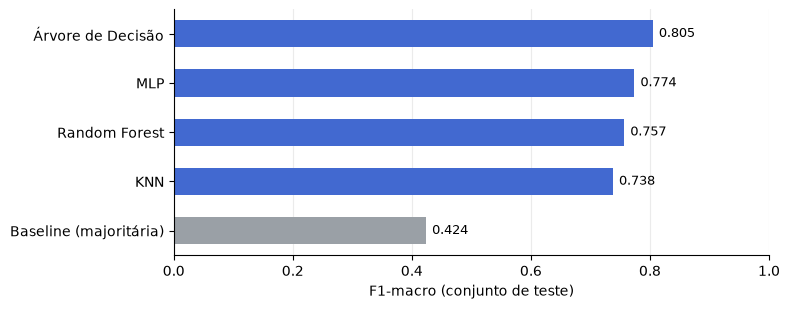

In [27]:
cores = ['#9aa0a6' if m.startswith('Baseline') else '#4269d0' for m in tabela['modelo']]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(tabela['modelo'], tabela['f1_macro'], color=cores, height=0.55)
for i, v in enumerate(tabela['f1_macro']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
ax.invert_yaxis()                      # melhor em cima
ax.set_xlabel('F1-macro (conjunto de teste)')
ax.set_xlim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_axisbelow(True); ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); plt.show()

In [28]:
melhor = tabela.iloc[0]
print('Melhor modelo :', melhor['modelo'])
print('  F1-macro    :', melhor['f1_macro'])
print('  Acurácia    :', melhor['acuracia'])
print('  Hiperparâmetros:', melhor['melhores_parametros'])

Melhor modelo : Árvore de Decisão
  F1-macro    : 0.805
  Acurácia    : 0.851
  Hiperparâmetros: {'max_depth': 3, 'min_samples_leaf': 5}


## 4.4 Interpretação — o que o melhor modelo aprendeu

A **Árvore de Decisão**, além de vencer na métrica, tem a vantagem de ser
interpretável: suas regras são legíveis. Visualizar os primeiros níveis mostra *quais
atributos* separam governista de oposição — informação central para a discussão do
trabalho.

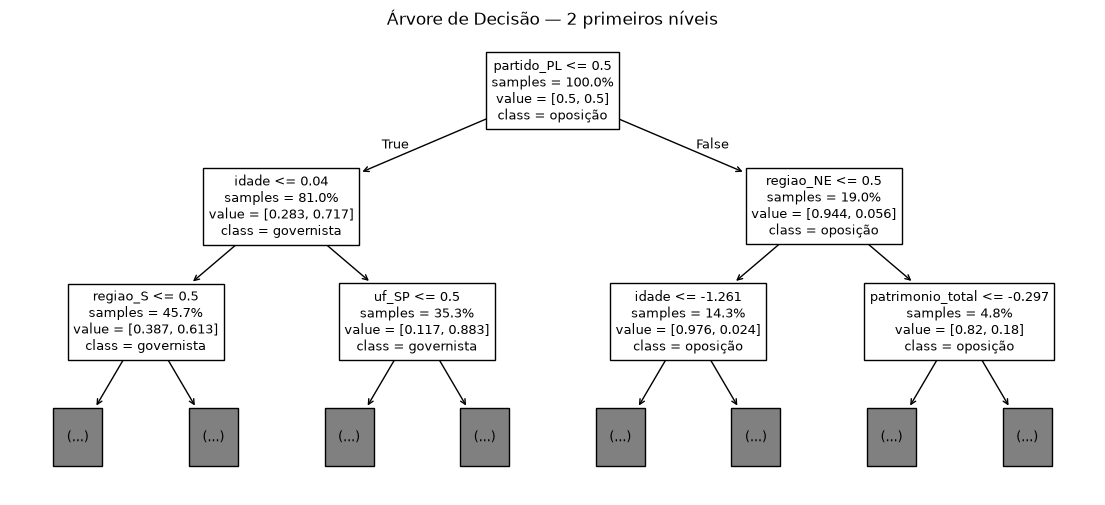

In [29]:
# árvore tunada pelo grid — 2 primeiros níveis, para leitura
arvore = buscas['Árvore de Decisão'].best_estimator_
nomes_feats = [n.split('__')[-1] for n in arvore.named_steps['pre'].get_feature_names_out()]

plt.figure(figsize=(14, 6))
plot_tree(arvore.named_steps['clf'], feature_names=nomes_feats,
          class_names=['oposição', 'governista'], max_depth=2,
          fontsize=9, impurity=False, proportion=True)
plt.title('Árvore de Decisão — 2 primeiros níveis')
plt.show()

## 4.5 Conclusão parcial (sem seleção de atributos)

| Modelo | Acurácia | F1-macro | Melhores hiperparâmetros |
|---|---|---|---|
| **Árvore de Decisão** | **0.851** | **0.805** | `max_depth=3`, `min_samples_leaf=5` |
| MLP | 0.824 | 0.774 | `hidden=(32,)`, `alpha=0.01` |
| Random Forest | 0.804 | 0.757 | `n_estimators=100`, `max_depth=8`, `min_samples_leaf=5` |
| KNN | 0.811 | 0.738 | `k=15`, `weights=uniform` |
| Baseline (majoritária) | 0.736 | 0.424 | — |

**Melhor até aqui: Árvore de Decisão** — melhor F1-macro (0.805) e o modelo mais
interpretável da comparação. Todos os algoritmos superam com folga o baseline
(F1 0.424), confirmando que o perfil eleitoral do TSE carrega sinal real sobre a
linha de atuação.

Observações:

- **A árvore vencedora usa `max_depth=3`:** bastam 3 níveis de regras (visíveis em
  §4.4, com `partido` na raiz) — o problema tem estrutura de decisão simples,
  dominada por poucos atributos.
- **Random Forest ficou atrás da árvore única** — coerente: o *ensemble* reduz
  variância, e uma árvore rasa e regularizada já tem variância baixa; o sorteio de
  atributos da floresta ainda dilui o sinal concentrado em poucas colunas de partido.
- **KNN foi o mais fraco** em F1 — distância euclidiana em espaço One-Hot esparso
  de 125 dimensões discrimina mal os vizinhos.

A observação sobre o KNN levanta uma hipótese: se o espaço tem 125 colunas mas o
sinal está concentrado em poucas, **reduzir as colunas antes do modelo** pode ajudar
os algoritmos sensíveis à dimensionalidade. A §4.6 testa isso.


## 4.6 Seleção de atributos (SelectKBest)

Hipótese: com 125 colunas esparsas e sinal concentrado em poucas, modelos sensíveis
à dimensionalidade (KNN, MLP) podem melhorar se receberem só os atributos mais
informativos.

Protocolo: um passo `SelectKBest(f_classif)` entra **dentro do pipeline**, entre o
pré-processamento e o classificador, e o número de colunas mantidas
`k ∈ {10, 20, 40, todas}` vira mais um hiperparâmetro da busca em grade — refitado
em cada partição da validação cruzada interna, portanto **sem vazamento**. Mesma
divisão treino/teste da §4.1.


In [30]:
from sklearn.feature_selection import SelectKBest, f_classif

f1_sem = tabela.set_index('modelo')['f1_macro']
resultados_sel = []
buscas_sel = {}
for nome, (modelo, grid) in modelos.items():
    if nome.startswith('Baseline'):
        continue
    pipe = Pipeline([('pre', preprocessador), ('sel', SelectKBest(f_classif)), ('clf', modelo)])
    busca = GridSearchCV(pipe, {**grid, 'sel__k': [10, 20, 40, 'all']},
                         scoring='f1_macro', cv=5, n_jobs=-1)
    busca.fit(X_treino, y_treino)
    pred = busca.predict(X_teste)
    resultados_sel.append({
        'modelo': nome,
        'f1_sem_sel': float(f1_sem[nome]),
        'f1_com_sel': f1_score(y_teste, pred, average='macro'),
        'acuracia_com_sel': accuracy_score(y_teste, pred),
        'k': busca.best_params_['sel__k'],
        'parametros': {k.replace('clf__', ''): v for k, v in busca.best_params_.items()
                       if k != 'sel__k'},
    })
    buscas_sel[nome] = busca

tabela_sel = pd.DataFrame(resultados_sel).sort_values('f1_com_sel', ascending=False).reset_index(drop=True)
tabela_sel[['f1_sem_sel', 'f1_com_sel', 'acuracia_com_sel']] = \
    tabela_sel[['f1_sem_sel', 'f1_com_sel', 'acuracia_com_sel']].round(3)
tabela_sel


,modelo,f1_sem_sel,f1_com_sel,acuracia_com_sel,k,parametros
0,MLP,0.774,0.853,0.892,20,"{'alpha': 0.01, 'hidden_layer_sizes': (32,)}"
1,Árvore de Decisão,0.805,0.805,0.851,all,"{'max_depth': 3, 'min_samples_leaf': 5}"
2,KNN,0.738,0.771,0.838,40,"{'n_neighbors': 5, 'weights': 'uniform'}"
3,Random Forest,0.757,0.757,0.804,all,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est..."


In [31]:
# quais atributos o seletor do vencedor (MLP, k=20) mantém — ajustado no treino
sel_mlp = buscas_sel['MLP'].best_estimator_
nomes_sel = sel_mlp.named_steps['pre'].get_feature_names_out()
mascara = sel_mlp.named_steps['sel'].get_support()
print('k escolhido pelo grid:', buscas_sel['MLP'].best_params_['sel__k'])
print(sorted(n.split('__')[1] for n in nomes_sel[mascara]))


k escolhido pelo grid: 20
['federacao_#NULO', 'federacao_PSOL/REDE', 'federacao_PT/PC do B/PV', 'ocupacao_MILITAR REFORMADO', 'ocupacao_POLICIAL MILITAR', 'ocupacao_PRODUTOR AGROPECUÁRIO', 'partido_MDB', 'partido_NOVO', 'partido_PDT', 'partido_PL', 'partido_PSD', 'partido_PT', 'partido_REPUBLICANOS', 'regiao_NE', 'regiao_S', 'uf_BA', 'uf_MT', 'uf_RO', 'uf_RS', 'uf_SC']


### Leitura da seleção

| Modelo | F1 sem seleção | F1 com seleção | k escolhido |
|---|---|---|---|
| **MLP** | 0.774 | **0.853** | **20** |
| KNN | 0.738 | 0.771 | 40 |
| Árvore de Decisão | 0.805 | 0.805 | todas |
| Random Forest | 0.757 | 0.757 | todas |

- **MLP é o grande beneficiado**: com as 20 melhores colunas, salta de 0.774 para
  **0.853** — passa a árvore e vira o melhor modelo da comparação. Com 442 amostras
  de treino, 20 entradas dão uma razão amostras/parâmetros muito mais saudável que
  125.
- **KNN também melhora** (0.738 → 0.771): menos dimensões esparsas, vizinhos mais
  significativos — confirma a hipótese da §4.5.
- **Árvore e Random Forest escolhem `k=all`**: árvores já fazem seleção implícita a
  cada split; pré-filtrar não tem o que melhorar.
- Os atributos selecionados são coerentes com a exploração (§2.5): colunas de
  partido e federação dominam, seguidas de região/UF e de ocupações ligadas à
  segurança pública e ao agro.

**Modelo escolhido para a validação: MLP (`hidden=(32,)`, `alpha=0.01`) +
`SelectKBest(k=20)`.** A árvore da §4.4 permanece como a *leitura interpretável* do
problema — ela mostra onde o sinal está; o MLP sobre os 20 melhores atributos é
quem melhor o explora.


# 5. Validação

A modelagem (§4) comparou os algoritmos com um **holdout único** — a estimativa
depende de uma divisão particular dos dados. Esta etapa mede o desempenho do modelo
escolhido na §4.6 (**MLP `hidden=(32,)`, `alpha=0.01` + `SelectKBest(k=20)`**) de
forma robusta.

## 5.1 Protocolo — validação cruzada estratificada repetida

- **Validação cruzada estratificada** com **10 folds**: a base (590) é dividida em 10
  partições preservando a proporção de classes (73,7% × 26,3%); treina-se em 9 e
  testa-se na décima, rotacionando — o desempenho é a média dos 10 folds.
- **Repetida 3×** com embaralhamentos diferentes → **30 medições**, permitindo
  reportar **média ± desvio padrão** (combina a validação cruzada com a ideia da
  amostragem aleatória: média de várias divisões).
- **Por que 10 folds:** treino com 90% dos dados (menos viés pessimista que 5 folds)
  e fold de teste com 59 amostras (~15 de oposição) — as métricas por fold ainda são
  bem definidas.
- **Por que não leave-one-out:** 590 ajustes por avaliação, sem estratificação, e F1
  indefinido em um fold de 1 amostra. Indicado para bases menores que esta.
- **Hiperparâmetros fixados** nos encontrados na §4.6. Honestidade metodológica: como o
  tuning usou 75% da base, os folds de teste desta seção contêm amostras que
  participaram daquela escolha — um viés otimista pequeno, aceito aqui em troca da
  simplicidade (a alternativa rigorosa seria validação aninhada, re-tunando dentro de
  cada fold).

In [32]:
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_predict

modelo_final = Pipeline([
    ('pre', preprocessador),
    ('sel', SelectKBest(f_classif, k=20)),
    ('clf', MLPClassifier(random_state=42, max_iter=2000,
                          hidden_layer_sizes=(32,), alpha=0.01)),
])

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
cv_res = cross_validate(modelo_final, X, y, cv=rskf,
                        scoring=['accuracy', 'f1_macro'], n_jobs=-1)

acc, f1m = cv_res['test_accuracy'], cv_res['test_f1_macro']
print(f'medições : {len(acc)} (10 folds × 3 repetições)')
print(f'acurácia : {acc.mean():.3f} ± {acc.std():.3f}  (min {acc.min():.3f} | max {acc.max():.3f})')
print(f'F1-macro : {f1m.mean():.3f} ± {f1m.std():.3f}  (min {f1m.min():.3f} | max {f1m.max():.3f})')

medições : 30 (10 folds × 3 repetições)
acurácia : 0.877 ± 0.042  (min 0.763 | max 0.949)
F1-macro : 0.832 ± 0.059  (min 0.711 | max 0.934)


/tmp/ipykernel_1288079/763755370.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([f1m, acc], tick_labels=['F1-macro', 'acurácia'], vert=False, widths=0.5)


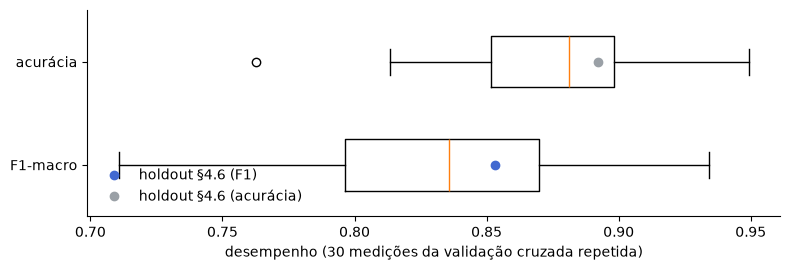

In [33]:
# distribuição das 30 medições — o holdout da §4 (ponto) dentro da variação da validação cruzada
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.boxplot([f1m, acc], tick_labels=['F1-macro', 'acurácia'], vert=False, widths=0.5)
ax.plot(0.853, 1, 'o', color='#4269d0', label='holdout §4.6 (F1)')
ax.plot(0.892, 2, 'o', color='#9aa0a6', label='holdout §4.6 (acurácia)')
ax.set_xlabel('desempenho (30 medições da validação cruzada repetida)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower left', frameon=False)
plt.tight_layout(); plt.show()

## 5.2 Matriz de confusão

Ilustra o número de predições corretas e incorretas em cada classe. Para usar **todos
os 590 deputados** como teste, as predições vêm de `cross_val_predict` com 10 folds
estratificados: cada deputado é previsto por um modelo que **não o viu** no treino.

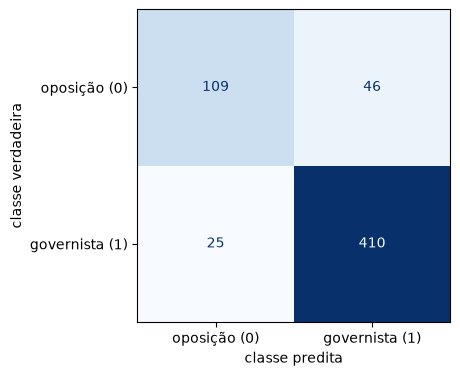

VP=410  FN=25  FP=46  VN=109  (n=590)


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
pred = cross_val_predict(modelo_final, X, y, cv=skf, n_jobs=-1)

cm = confusion_matrix(y, pred)   # linhas = classe verdadeira, colunas = predita
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=['oposição (0)', 'governista (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_xlabel('classe predita'); ax.set_ylabel('classe verdadeira')
plt.tight_layout(); plt.show()

# notação dos slides (positiva = governista): VP, FN / FP, VN
(vn, fp), (fn, vp) = cm
print(f'VP={vp}  FN={fn}  FP={fp}  VN={vn}  (n={vp+vn+fp+fn})')

## 5.3 Medidas de desempenho por classe

Derivadas da matriz de confusão (classe positiva = governista):

- **Sensibilidade / revocação** = VP/(VP+FN) — taxa de acerto na classe positiva;
- **Especificidade** = VN/(VN+FP) — taxa de acerto na classe negativa
  (equivale à revocação da classe oposição);
- **Precisão** = VP/(VP+FP) — dos preditos como positivos, quantos são de fato;
- **Medida-F1** = média harmônica de precisão e revocação (peso igual).

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y, pred, target_names=['oposição', 'governista'], digits=3))

sens = vp / (vp + fn)
esp  = vn / (vn + fp)
prec = vp / (vp + fp)
print(f'sensibilidade/revocação (governista): {sens:.3f}')
print(f'especificidade (acerto na oposição) : {esp:.3f}')
print(f'precisão (governista)               : {prec:.3f}')

              precision    recall  f1-score   support

    oposição      0.813     0.703     0.754       155
  governista      0.899     0.943     0.920       435

    accuracy                          0.880       590
   macro avg      0.856     0.823     0.837       590
weighted avg      0.877     0.880     0.877       590

sensibilidade/revocação (governista): 0.943
especificidade (acerto na oposição) : 0.703
precisão (governista)               : 0.899


## 5.4 Análise de erros

Onde o modelo erra? Como o sinal é dominado por partido (§4.4 e §4.6), o erro deve
se concentrar em deputados cujo **partido não determina** a linha de atuação —
legendas divididas entre governo e oposição.


In [36]:
analise = df[['nome', 'partido', 'uf', 'rotulo']].copy()
analise['pred'] = np.where(pred == 1, 'governista', 'oposicao')
analise['erro'] = analise['pred'] != analise['rotulo']

por_partido = (analise.groupby('partido')
               .agg(deputados=('erro', 'size'),
                    erros=('erro', 'sum'),
                    pct_governista=('rotulo', lambda r: (r == 'governista').mean()))
               .assign(taxa_erro=lambda t: t['erros'] / t['deputados'])
               .sort_values('erros', ascending=False))
por_partido['pct_governista'] = por_partido['pct_governista'].round(2)
por_partido['taxa_erro'] = por_partido['taxa_erro'].round(2)
print('total de erros:', int(analise["erro"].sum()), 'de', len(analise))
por_partido.head(10)

total de erros: 71 de 590


,deputados,erros,pct_governista,taxa_erro
partido,,,,
UNIÃO,67,18,0.73,0.27
PL,112,16,0.13,0.14
PP,56,10,0.77,0.18
MDB,48,8,0.88,0.17
PSD,57,6,0.91,0.11
PODE,15,3,0.80,0.20
REPUBLICANOS,47,3,0.94,0.06
PATRIOTA,6,2,0.67,0.33
PSOL,13,1,1.00,0.08


## 5.5 Conclusão da validação

| Medida | Valor |
|---|---|
| Acurácia (30 medições) | **0.877 ± 0.042** |
| F1-macro (30 medições) | **0.832 ± 0.059** |
| Sensibilidade/revocação (governista) | 0.943 |
| Especificidade (acerto na oposição) | 0.703 |
| Precisão (governista) | 0.899 |

- **O holdout da §4.6 era otimista.** A validação cruzada repetida estima o
  desempenho real em acurácia ~0.88 e F1 ~0.83 — o holdout (0.892 / 0.853) caiu
  acima da média das 30 medições (visível no boxplot da §5.1). É exatamente para
  expor isso que a validação usa várias divisões em vez de uma. A conclusão
  qualitativa não muda: bem acima do baseline (F1 0.424) e da árvore sem seleção
  (F1 0.758 ± 0.052 no mesmo protocolo).
- **Compromisso entre as classes:** o MLP acerta 94% dos governistas e 70% da
  oposição. É um recorte diferente do da árvore com `class_weight=balanced`
  (~79% em cada classe): o F1-macro total sobe de 0.758 para 0.832, ao custo de um
  leve deslocamento pró-classe majoritária — registrado como escolha consciente,
  guiada pela métrica de decisão do trabalho.
- **Onde o modelo erra (§5.4):** o padrão estrutural se mantém — os erros (71 no
  total, contra 125 da árvore) continuam concentrados nas legendas **divididas**:
  UNIÃO (18) e PL (16) respondem por quase metade. Quando o partido não determina a
  posição, o perfil demográfico pré-eleição não é suficiente.
- **Resposta à pergunta do trabalho:** sim, é possível prever a linha de atuação só
  com os dados de candidatura do TSE — F1-macro real de **0.832 ± 0.059** (contra
  0.424 do chute na classe majoritária). O sinal vem majoritariamente do partido e
  da federação; a seleção de atributos (§4.6) mostrou que 20 colunas bastam — e um
  MLP compacto sobre elas é quem melhor explora esse sinal.


# 6. Experimento de robustez — prever sem o partido

A conclusão da validação (§5.5) aponta a filiação partidária como fonte dominante
do sinal. Pergunta natural (e provável na arguição): **o modelo aprende algo além
do partido?** Teste de ablação, repetindo o protocolo completo da modelagem
(holdout estratificado 75/25, `GridSearchCV` com `SelectKBest` na grade — §4.6)
em duas variantes:

- **A — sem `partido`:** mantém `federacao`, que pode agir como *proxy* direto da
  filiação (ex.: `PT/PC do B/PV` revela o campo político);
- **B — sem `partido` e sem `federacao`:** remove toda a informação de filiação —
  restam demografia (idade, gênero, instrução, cor/raça, ocupação, patrimônio) e
  geografia (UF, região).

A coluna `partido` continua disponível para a **análise** de erros — só não entra
nas features.

In [37]:
VARIANTES = {
    'A: sem partido': [c for c in CATEGORICAS if c != 'partido'],
    'B: sem partido e federacao': [c for c in CATEGORICAS if c not in ('partido', 'federacao')],
}

resultados_abl = []
buscas_abl = {}
for var, cats in VARIANTES.items():
    pre_v = ColumnTransformer([
        ('cat', Pipeline([('imput', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cats),
        ('num', Pipeline([('imput', SimpleImputer(strategy='median')),
                          ('escala', StandardScaler())]), NUMERICAS),
    ])
    for nome, (modelo, grid) in modelos.items():
        if nome.startswith('Baseline'):
            continue
        pipe = Pipeline([('pre', pre_v), ('sel', SelectKBest(f_classif)), ('clf', modelo)])
        busca = GridSearchCV(pipe, {**grid, 'sel__k': [10, 20, 40, 'all']},
                             scoring='f1_macro', cv=5, n_jobs=-1)
        busca.fit(X_treino[cats + NUMERICAS], y_treino)
        p = busca.predict(X_teste[cats + NUMERICAS])
        resultados_abl.append({
            'variante': var, 'modelo': nome,
            'acuracia': accuracy_score(y_teste, p),
            'f1_macro': f1_score(y_teste, p, average='macro'),
            'k': busca.best_params_['sel__k'],
        })
        buscas_abl[(var, nome)] = busca

tabela_abl = (pd.DataFrame(resultados_abl)
              .sort_values(['variante', 'f1_macro'], ascending=[True, False])
              .reset_index(drop=True))
tabela_abl[['acuracia', 'f1_macro']] = tabela_abl[['acuracia', 'f1_macro']].round(3)
tabela_abl

,variante,modelo,acuracia,f1_macro,k
0,A: sem partido,MLP,0.723,0.566,40
1,A: sem partido,Random Forest,0.595,0.555,all
2,A: sem partido,Árvore de Decisão,0.622,0.520,40
3,A: sem partido,KNN,0.703,0.515,all
4,B: sem partido e federacao,KNN,0.716,0.538,all
5,B: sem partido e federacao,MLP,0.662,0.532,all
6,B: sem partido e federacao,Random Forest,0.649,0.504,all
7,B: sem partido e federacao,Árvore de Decisão,0.554,0.497,40


In [38]:
# validação cruzada repetida (mesmo protocolo da §5.1) do melhor modelo de cada variante
melhores_abl = {}
linhas = []
for var, cats in VARIANTES.items():
    t = tabela_abl[tabela_abl['variante'] == var].iloc[0]
    est = buscas_abl[(var, t['modelo'])].best_estimator_
    melhores_abl[var] = (t['modelo'], est, cats)
    cv = cross_validate(est, X[cats + NUMERICAS], y, cv=rskf,
                        scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    linhas.append({'variante': var, 'melhor_modelo': f"{t['modelo']} (k={t['k']})",
                   'f1_holdout': t['f1_macro'],
                   'f1_cv': cv['test_f1_macro'].mean(), 'f1_cv_dp': cv['test_f1_macro'].std(),
                   'acuracia_cv': cv['test_accuracy'].mean()})

linhas.append({'variante': 'completo (referência §5)', 'melhor_modelo': 'MLP (k=20)',
               'f1_holdout': 0.853, 'f1_cv': f1m.mean(), 'f1_cv_dp': f1m.std(),
               'acuracia_cv': acc.mean()})
linhas.append({'variante': 'baseline (majoritária)', 'melhor_modelo': '—',
               'f1_holdout': 0.424, 'f1_cv': np.nan, 'f1_cv_dp': np.nan,
               'acuracia_cv': np.nan})
pd.DataFrame(linhas).round(3)

,variante,melhor_modelo,f1_holdout,f1_cv,f1_cv_dp,acuracia_cv
0,A: sem partido,MLP (k=40),0.566,0.567,0.057,0.689
1,B: sem partido e federacao,KNN (k=all),0.538,0.518,0.072,0.732
2,completo (referência §5),MLP (k=20),0.853,0.832,0.059,0.877
3,baseline (majoritária),—,0.424,NaN,NaN,NaN


In [39]:
# matriz de confusão e erros por partido (cross_val_predict, mesmo protocolo da §5.2)
for var, (nome, est, cats) in melhores_abl.items():
    p = cross_val_predict(est, X[cats + NUMERICAS], y, cv=skf, n_jobs=-1)
    (vn_, fp_), (fn_, vp_) = confusion_matrix(y, p)
    top = (df.assign(erro=(p != y.values)).groupby('partido')['erro'].sum()
           .sort_values(ascending=False).head(5).astype(int))
    print(f'{var} — {nome}')
    print(f'  VP={vp_}  FN={fn_}  FP={fp_}  VN={vn_}  | erros={fp_ + fn_} de {len(y)}')
    print(f'  recall governista={vp_ / (vp_ + fn_):.3f} | recall oposição={vn_ / (vn_ + fp_):.3f}')
    print(f'  top 5 partidos por erros: {dict(top)}')
    # quais features o seletor da variante manteve (fit no treino)
    if est.named_steps['sel'].k != 'all':
        nomes_v = est.named_steps['pre'].get_feature_names_out()
        mantidas = sorted(n.split('__')[1] for n in nomes_v[est.named_steps['sel'].get_support()])
        print(f'  features mantidas pelo SelectKBest: {mantidas}')
    print()

A: sem partido — MLP
  VP=368  FN=67  FP=109  VN=46  | erros=176 de 590
  recall governista=0.846 | recall oposição=0.297
  top 5 partidos por erros: {'PL': np.int64(73), 'PP': np.int64(22), 'UNIÃO': np.int64(21), 'MDB': np.int64(15), 'REPUBLICANOS': np.int64(13)}
  features mantidas pelo SelectKBest: ['cor_raca_AMARELA', 'cor_raca_BRANCA', 'cor_raca_PARDA', 'federacao_#NULO', 'federacao_PSOL/REDE', 'federacao_PT/PC do B/PV', 'grau_instrucao_ENSINO FUNDAMENTAL INCOMPLETO', 'grau_instrucao_SUPERIOR COMPLETO', 'idade', 'ocupacao_AGRICULTOR', 'ocupacao_APOSENTADO (EXCETO SERVIDOR PÚBLICO)', 'ocupacao_ARQUITETO', 'ocupacao_CIENTISTA POLÍTICO', 'ocupacao_COMERCIANTE', 'ocupacao_DONA DE CASA', 'ocupacao_ESCRITOR E CRÍTICO', 'ocupacao_JORNALISTA E REDATOR', 'ocupacao_MEMBRO DAS FORÇAS ARMADAS', 'ocupacao_MILITAR REFORMADO', 'ocupacao_OUTROS', 'ocupacao_POLICIAL CIVIL', 'ocupacao_POLICIAL MILITAR', 'ocupacao_PRODUTOR AGROPECUÁRIO', 'ocupacao_PSICÓLOGO', 'ocupacao_SENADOR', 'patrimonio_total', 

## 6.1 Leitura do experimento

| Configuração | Melhor modelo | F1 holdout | F1 CV (10×3) | Recall oposição |
|---|---|---|---|---|
| Completo (§5) | MLP (k=20) | 0,853 | **0,832 ± 0,059** | 0,703 |
| A: sem `partido` | MLP (k=40) | 0,566 | **0,567 ± 0,057** | 0,297 |
| B: sem `partido` e `federacao` | KNN (todas) | 0,538 | **0,518 ± 0,072** | 0,129 |
| Baseline (majoritária) | — | 0,424 | — | 0,000 |

- **O sinal é quase todo filiação partidária.** Sem `partido`, o F1 real cai de
  0,832 para 0,567; removendo também `federacao`, para 0,518 — pouco acima do
  baseline (0,424). Demografia + geografia sozinhas carregam sinal marginal.
- **`federacao` age como proxy parcial da filiação** (variante A): o seletor a
  mantém entre as features, mas ela só identifica o campo à esquerda
  (`PT/PC do B/PV`, `PSOL/REDE`). A oposição — concentrada no PL, que não tem
  federação — fica invisível: o PL sozinho responde por 73 dos 176 erros.
- **Sem filiação alguma (variante B), o modelo quase colapsa na classe
  majoritária:** recall da oposição de 0,129 (contra 0,703 no modelo completo).
  O ganho residual de F1 sobre o baseline vem de traços demográficos fracos
  (ocupações de segurança pública/agro, região Sul).
- **Conclusão do experimento:** confirma e quantifica a leitura da §5.5 — o
  perfil TSE prevê a linha de atuação *porque* contém a filiação partidária;
  quando ela é removida (ou, na prática, quando a legenda é dividida e ela não
  informa), o restante do formulário de candidatura não sustenta a previsão.